# IMAGE COLOR COMPRESSION USING K-MEANS CLUSTERING

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

In [4]:
import cv2

butterfly = cv2.imread("Dataset/butterfly.jpeg")
barnowl = cv2.imread("Dataset/barnowl.jpeg")

print(butterfly.shape, butterfly.dtype)
print(barnowl.shape, barnowl.dtype)

(529, 529, 3) uint8
(516, 387, 3) uint8


# 1. The images

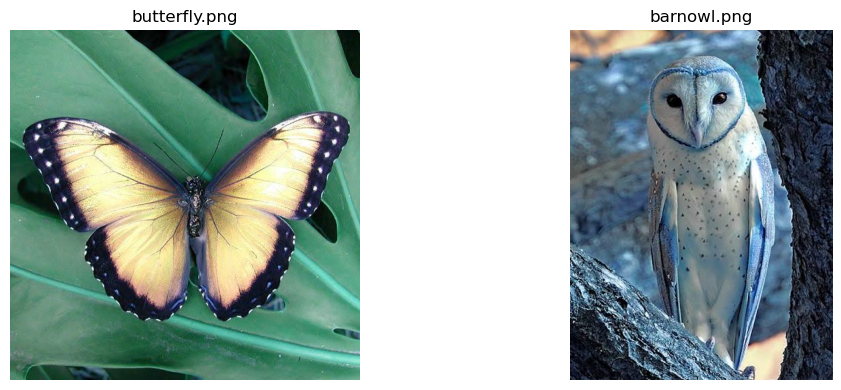

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(butterfly);  ax[0].set_title('butterfly.png');  ax[0].axis('off')
ax[1].imshow(barnowl); ax[1].set_title('barnowl.png'); ax[1].axis('off')
plt.tight_layout(); plt.show()

In [9]:
for name, img in [('butterfly', butterfly), ('barnowl', barnowl)]:
    h, w, c = img.shape
    n_pixels = h * w
    n_colors = len(np.unique(img.reshape(-1, 3), axis=0))
    print(f'{name:7s} | {h}x{w} = {n_pixels:,} pixels | {n_colors:,} unique colours '
          f'| {100*n_colors/n_pixels:5.1f}% of pixels are a unique colour')

butterfly | 529x529 = 279,841 pixels | 90,051 unique colours |  32.2% of pixels are a unique colour
barnowl | 516x387 = 199,692 pixels | 61,202 unique colours |  30.6% of pixels are a unique colour


# 2. Dataset overview

# 3. Colour-channel distributions (BUTTERFLY)

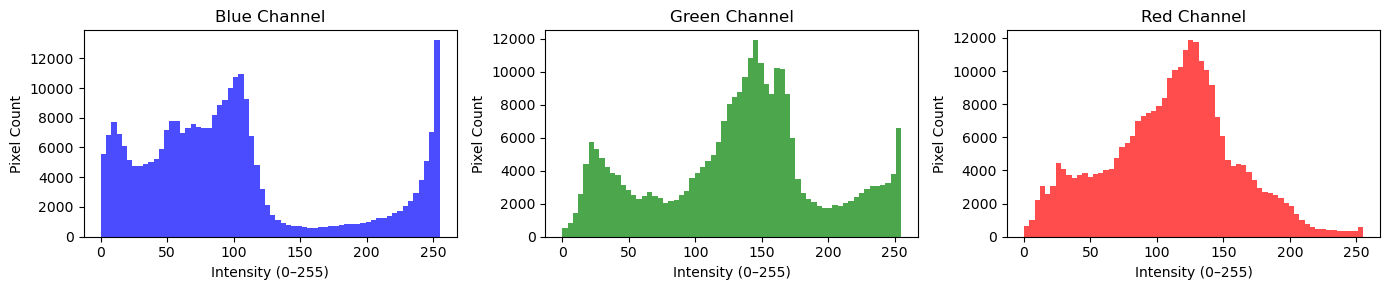

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))

colors = ['blue', 'green', 'red']

for i, col in enumerate(colors):
    ax[i].hist(butterfly[..., i].ravel(), bins=64, color=col, alpha=0.7)
    ax[i].set_title(f'{col.capitalize()} Channel')
    ax[i].set_xlabel('Intensity (0–255)')
    ax[i].set_ylabel('Pixel Count')

plt.tight_layout()
plt.show()

# 3. Colour-channel distributions (BARNOWL)

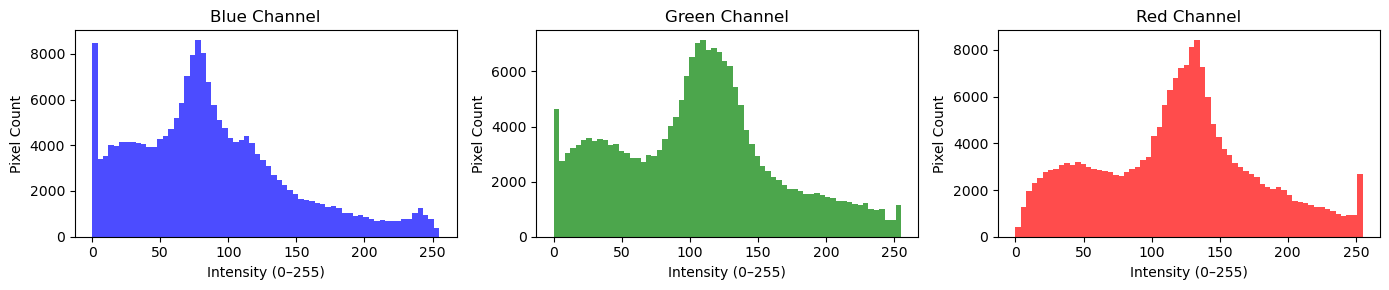

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3))

colors = ['blue', 'green', 'red']

for i, col in enumerate(colors):
    ax[i].hist(barnowl[..., i].ravel(), bins=64, color=col, alpha=0.7)
    ax[i].set_title(f'{col.capitalize()} Channel')
    ax[i].set_xlabel('Intensity (0–255)')
    ax[i].set_ylabel('Pixel Count')

plt.tight_layout()
plt.show()

# 4. Pixels in RGB space (BUTTERFLY)

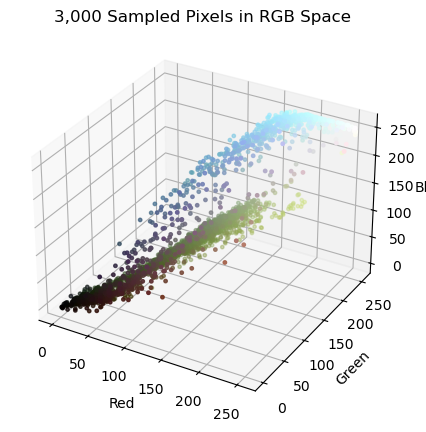

In [18]:
from mpl_toolkits.mplot3d import Axes3D

butterfly_rgb = cv2.cvtColor(butterfly, cv2.COLOR_BGR2RGB)

X = butterfly_rgb.reshape(-1, 3)

rng = np.random.RandomState(42)
idx = rng.choice(len(X), 3000, replace=False)
sample = X[idx]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    sample[:, 0],
    sample[:, 1],
    sample[:, 2],
    c=sample / 255.0,  
    s=6
)

ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")
ax.set_title("3,000 Sampled Pixels in RGB Space")

plt.show()

# 4 Pixels in RGB space (BARNOWL)

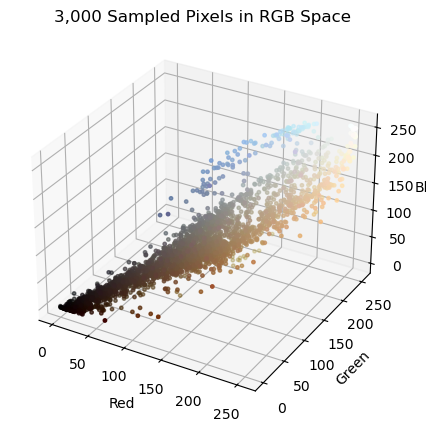

In [20]:
barnowl_rgb = cv2.cvtColor(barnowl, cv2.COLOR_BGR2RGB)

X = barnowl_rgb.reshape(-1, 3)

rng = np.random.RandomState(42)
idx = rng.choice(len(X), 3000, replace=False)
sample = X[idx]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    sample[:, 0],
    sample[:, 1],
    sample[:, 2],
    c=sample / 255.0,  
    s=6
)

ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")
ax.set_title("3,000 Sampled Pixels in RGB Space")

plt.show()

# 5. Summary of findings